# Agricultural Drought Prediction for Eastern Croatia
## Using Copernicus Satellite Data (ERA5-Land + ESA CCI Soil Moisture)

| | |
|---|---|
| **Region** | Eastern Croatia (Slavonia) — lat 45.0–45.8 °N, lon 17.5–19.0 °E |
| **Period** | 2003–2024 (monthly) |
| **Models** | Random Forest · XGBoost · K-Nearest Neighbors |
| **Target** | Binary: normal (0) vs drought (1) — predicted **2 months ahead** |

### Workflow
1. `prepare_dataset.ipynb` — loads raw data, computes SSI-3 labels, feature engineering, saves `data/dataset.csv`
2. Load dataset → define features → train models → evaluate → save

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings, os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")

# ── Project directories ───────────────────────────────────────────────────────
DATA_DIR   = Path("data")
PLOTS_DIR  = Path("plots")
MODELS_DIR = Path("models")
for d in [DATA_DIR, PLOTS_DIR, MODELS_DIR]:
    d.mkdir(exist_ok=True)

print("Setup complete.")
print(f"  data    → {DATA_DIR.resolve()}")
print(f"  plots   → {PLOTS_DIR.resolve()}")
print(f"  models  → {MODELS_DIR.resolve()}")

Setup complete.
  data    → C:\Users\KristinaNikolic\Local files\AI Lipik\ZAVRŠNI PROJEKT\data
  plots   → C:\Users\KristinaNikolic\Local files\AI Lipik\ZAVRŠNI PROJEKT\plots
  models  → C:\Users\KristinaNikolic\Local files\AI Lipik\ZAVRŠNI PROJEKT\models


---
## Load Dataset

In [2]:
# Load the preprocessed dataset produced by prepare_dataset.ipynb
DATASET_FILE = DATA_DIR / "dataset.csv"

if not DATASET_FILE.exists():
    raise FileNotFoundError(
        "data/dataset.csv not found. Run prepare_dataset.ipynb first."
    )

df = pd.read_csv(DATASET_FILE, parse_dates=["time"])
df = df.sort_values(["time", "lat", "lon"]).reset_index(drop=True)

print(f"Dataset loaded: {df.shape}")
print(f"Time range: {df['time'].min().date()} → {df['time'].max().date()}")
print(f"Columns: {list(df.columns)}")
print(f"Drought fraction (2-month target): {df['drought_2months'].mean():.1%}")

Dataset loaded: (37296, 29)
Time range: 2003-04-01 → 2024-10-01
Columns: ['time', 'lat', 'lon', 'd2m', 't2m', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'ssr', 'pev', 'e', 'tp', 'sat_sm', 'month', 'sm_rootzone', 'sm_smooth', 'clim_mean', 'clim_std', 'sm_anomaly', 'drought_binary', 'drought_2months', 'swvl1_lag1', 'swvl1_lag2', 'swvl1_lag3', 'tp_roll3', 't2m_roll3', 'tp_clim_mean', 'tp_deficit']
Drought fraction (2-month target): 33.1%


In [3]:
# ── Define features and target ────────────────────────────────────────────────
# All features were computed in prepare_dataset.ipynb and are already in the CSV.
ERA5_VARS = ["d2m", "t2m", "swvl1", "swvl2", "swvl3", "swvl4",
             "ssr", "pev", "e", "tp"]
ERA5_VARS = [v for v in ERA5_VARS if v in df.columns]

FEATURE_COLS = (
    ERA5_VARS
    + ["sat_sm", "sm_rootzone", "sm_anomaly", "month"]
    + ["swvl1_lag1", "swvl1_lag2", "swvl1_lag3"]
    + ["tp_roll3", "t2m_roll3", "tp_deficit"]
)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

TARGET_COL = "drought_2months"
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")

Features (20): ['d2m', 't2m', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'ssr', 'pev', 'e', 'tp', 'sat_sm', 'sm_rootzone', 'sm_anomaly', 'month', 'swvl1_lag1', 'swvl1_lag2', 'swvl1_lag3', 'tp_roll3', 't2m_roll3', 'tp_deficit']
Target: drought_2months


---
## Step 5 — Train Models

**Time-based split** (prevents data leakage):
- Train: 2003–2019
- Test:  2020–2024

**Forecast horizon: 2 months ahead** — features from month T predict drought
at month T+2. Supported by RegCDI research showing soil-moisture-based indicators
can predict drought up to 2 months ahead with ≥80% accuracy.

Class imbalance is addressed with **SMOTE** (Synthetic Minority Oversampling)
applied **only to the training set**.

In [4]:
# ── Time-based train / test split ────────────────────────────────────────────
TRAIN_END = pd.Timestamp("2019-12-31")
TEST_START = pd.Timestamp("2020-01-01")

train_mask = df["time"] <= TRAIN_END
test_mask  = df["time"] >= TEST_START

X_train = df.loc[train_mask, FEATURE_COLS].values
y_train = df.loc[train_mask, TARGET_COL].values
X_test  = df.loc[test_mask,  FEATURE_COLS].values
y_test  = df.loc[test_mask,  TARGET_COL].values

print(f"Train samples: {len(X_train):,}  ({y_train.mean():.1%} drought)")
print(f"Test  samples: {len(X_test):,}  ({y_test.mean():.1%} drought)")

Train samples: 28,944  (29.1% drought)
Test  samples: 8,352  (47.2% drought)


In [5]:
# ── Apply SMOTE to training set ───────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — Train samples: {len(X_train_res):,}")
print(f"  Class 0 (normal):  {(y_train_res == 0).sum():,}")
print(f"  Class 1 (drought): {(y_train_res == 1).sum():,}")

After SMOTE — Train samples: 41,052
  Class 0 (normal):  20,526
  Class 1 (drought): 20,526


In [6]:
# ── 1. Random Forest ─────────────────────────────────────────────────────────
print("Training Random Forest …")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_res, y_train_res)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
print("  Random Forest — done")

Training Random Forest …
  Random Forest — done


In [7]:
# ── 2. XGBoost ───────────────────────────────────────────────────────────────
print("Training XGBoost …")
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb_clf.fit(X_train_res, y_train_res)
xgb_pred  = xgb_clf.predict(X_test)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]
print("  XGBoost — done")

Training XGBoost …
  XGBoost — done


In [8]:
# ── 3. K-Nearest Neighbours (with scaling) ───────────────────────────────────
print("Training KNN …")
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=15, metric="euclidean", n_jobs=-1)),
])
knn_pipe.fit(X_train_res, y_train_res)
knn_pred  = knn_pipe.predict(X_test)
knn_proba = knn_pipe.predict_proba(X_test)[:, 1]
print("  KNN — done")

print("\nAll models trained successfully.")

Training KNN …
  KNN — done

All models trained successfully.


---
## Step 6 — Evaluation & Visualisations

In [9]:
# ── Classification reports ───────────────────────────────────────────────────
models = {
    "Random Forest": (rf_pred,  rf_proba),
    "XGBoost":       (xgb_pred, xgb_proba),
    "KNN":           (knn_pred, knn_proba),
}

reports = {}
for name, (pred, _) in models.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    report = classification_report(y_test, pred, target_names=["Normal", "Drought"])
    print(report)
    reports[name] = classification_report(y_test, pred, output_dict=True)

  Random Forest
              precision    recall  f1-score   support

      Normal       0.78      0.75      0.76      4414
     Drought       0.73      0.77      0.75      3938

    accuracy                           0.76      8352
   macro avg       0.76      0.76      0.76      8352
weighted avg       0.76      0.76      0.76      8352

  XGBoost
              precision    recall  f1-score   support

      Normal       0.80      0.75      0.77      4414
     Drought       0.74      0.79      0.76      3938

    accuracy                           0.77      8352
   macro avg       0.77      0.77      0.77      8352
weighted avg       0.77      0.77      0.77      8352

  KNN
              precision    recall  f1-score   support

      Normal       0.73      0.59      0.65      4414
     Drought       0.62      0.76      0.68      3938

    accuracy                           0.67      8352
   macro avg       0.68      0.67      0.67      8352
weighted avg       0.68      0.67      0.6

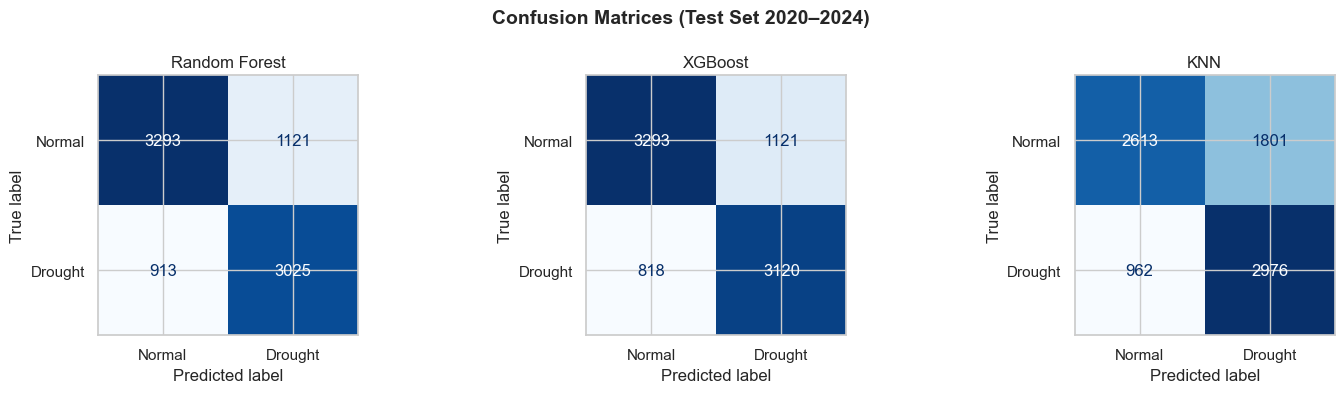

Saved: plots/confusion_matrices.png


In [10]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices (Test Set 2020–2024)", fontsize=14, fontweight="bold")

for ax, (name, (pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Drought"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/confusion_matrices.png")

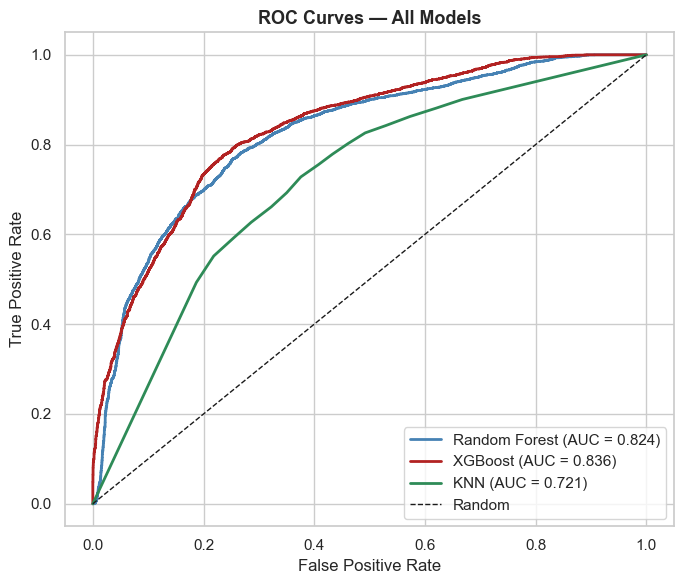

Saved: plots/roc_curves.png


In [11]:
# ── ROC curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["steelblue", "firebrick", "seagreen"]

for (name, (_, proba)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/roc_curves.png")

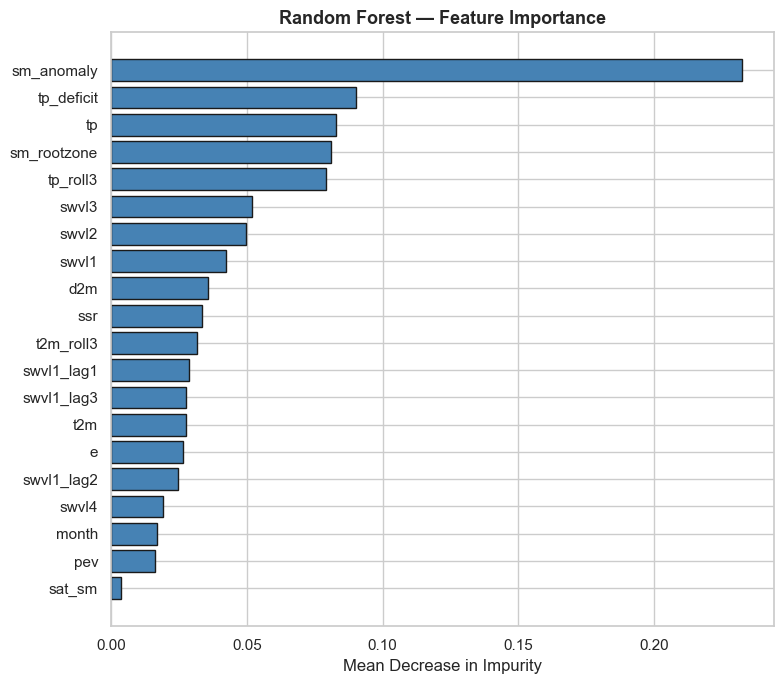

Saved: plots/feature_importance.png


In [12]:
# ── Feature importance (Random Forest) ───────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(5, len(importances) * 0.35)))
bars = ax.barh(importances.index, importances.values, color="steelblue", edgecolor="k")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest — Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/feature_importance.png")

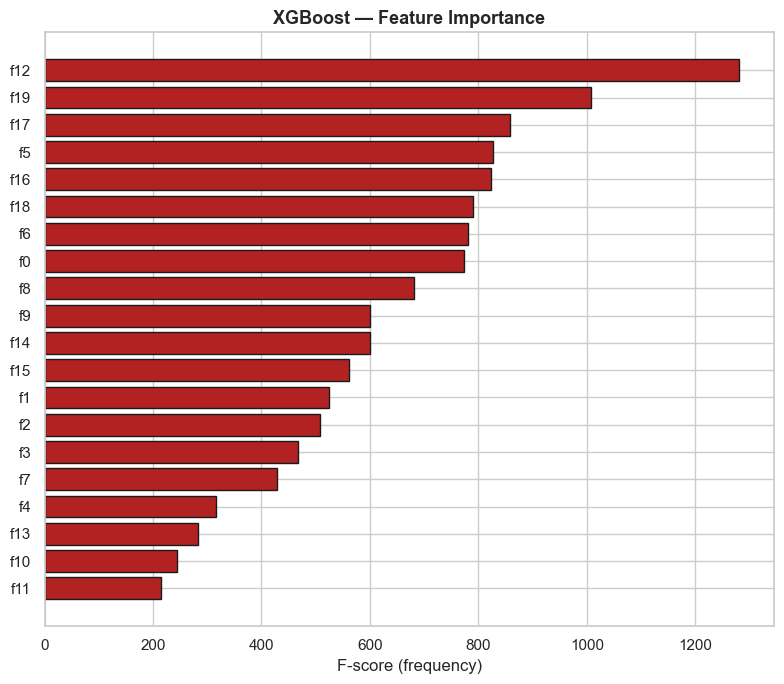

Saved: plots/feature_importance_xgb.png


In [13]:
# ── XGBoost feature importance (gain) ────────────────────────────────────────
xgb_imp = pd.Series(
    xgb_clf.get_booster().get_fscore(),
    name="importance"
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(5, len(xgb_imp) * 0.35)))
ax.barh(xgb_imp.index, xgb_imp.values, color="firebrick", edgecolor="k")
ax.set_xlabel("F-score (frequency)")
ax.set_title("XGBoost — Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "feature_importance_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/feature_importance_xgb.png")

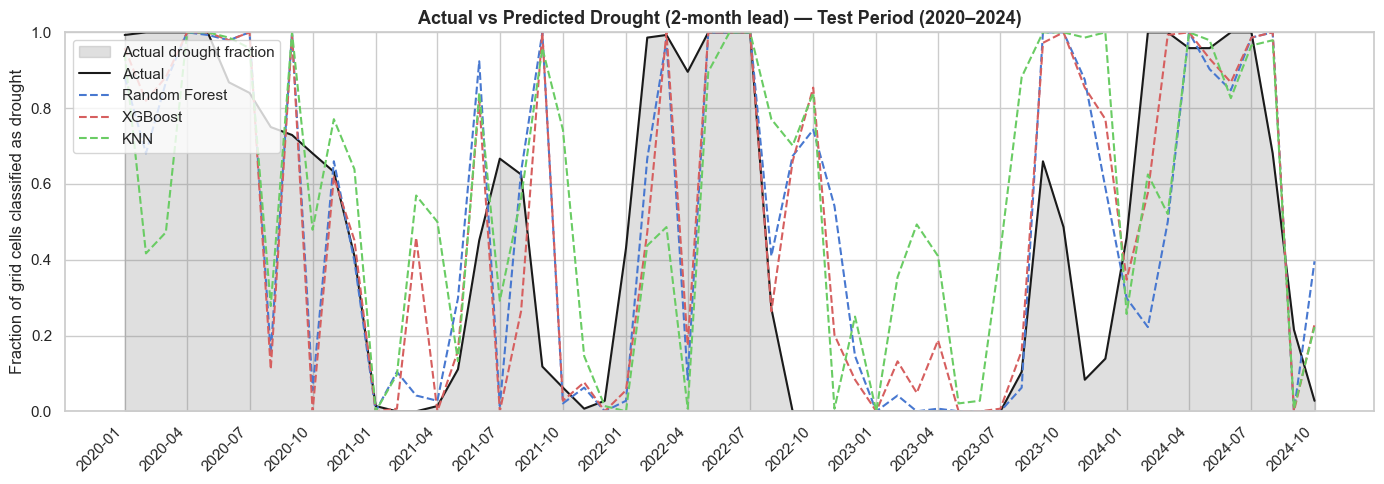

Saved: plots/timeline_actual_vs_predicted.png


In [14]:
# ── Timeline: actual vs predicted drought (2020-2024) ────────────────────────
# Aggregate to monthly fraction of drought-labelled grid cells
test_df = df.loc[df["time"] >= TEST_START].copy().reset_index(drop=True)
test_df["rf_pred"]  = rf_pred
test_df["xgb_pred"] = xgb_pred
test_df["knn_pred"] = knn_pred

monthly = test_df.groupby("time").agg(
    actual   = (TARGET_COL, "mean"),
    rf_pred  = ("rf_pred",  "mean"),
    xgb_pred = ("xgb_pred", "mean"),
    knn_pred = ("knn_pred", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly["time"], monthly["actual"], alpha=0.25,
                color="gray", label="Actual drought fraction")
ax.plot(monthly["time"], monthly["actual"],  "k-",  lw=1.5, label="Actual")
ax.plot(monthly["time"], monthly["rf_pred"], "b--", lw=1.5, label="Random Forest")
ax.plot(monthly["time"], monthly["xgb_pred"],"r--", lw=1.5, label="XGBoost")
ax.plot(monthly["time"], monthly["knn_pred"],"g--", lw=1.5, label="KNN")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
ax.set_ylabel("Fraction of grid cells classified as drought")
ax.set_title("Actual vs Predicted Drought (2-month lead) — Test Period (2020–2024)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "timeline_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/timeline_actual_vs_predicted.png")

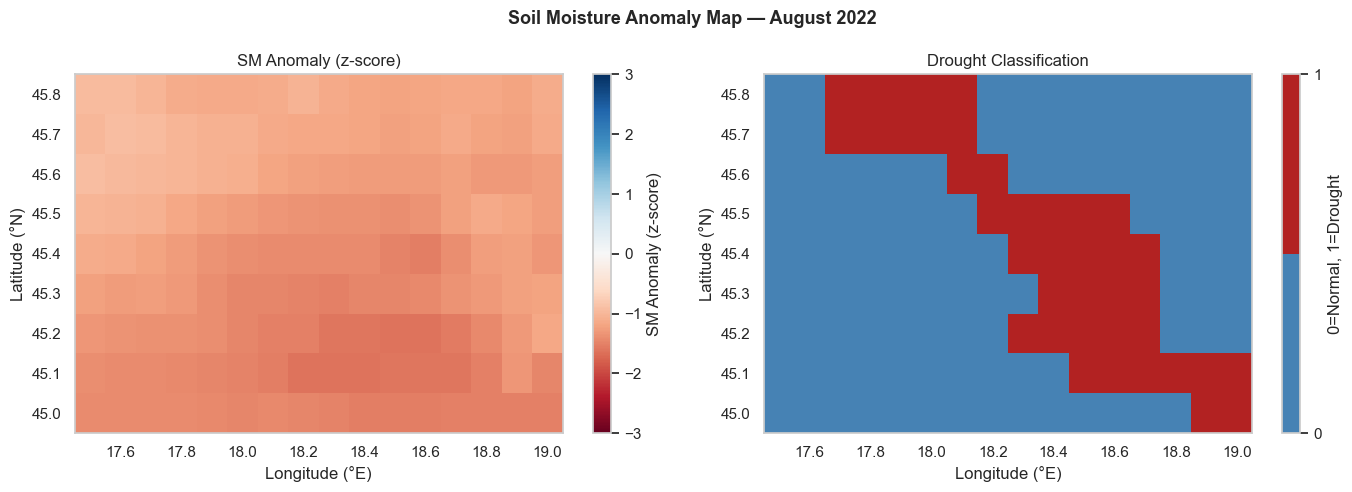

Saved: plots/anomaly_map.png  (showing August 2022)


In [15]:
# ── Soil moisture anomaly map ─────────────────────────────────────────────────
# Use summer 2022 — a documented severe drought year in the region
DROUGHT_MONTH = pd.Timestamp("2022-08-01")

# Find nearest available month
available = df["time"].unique()
nearest = min(available, key=lambda t: abs(t - DROUGHT_MONTH))

snap = df[df["time"] == nearest].copy()

# Pivot to 2-D grid
pivot = snap.pivot_table(index="lat", columns="lon", values="sm_anomaly")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Soil Moisture Anomaly Map — {pd.Timestamp(nearest).strftime('%B %Y')}",
             fontsize=13, fontweight="bold")

# Anomaly map
cmap_div = plt.cm.RdBu
norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
im1 = axes[0].pcolormesh(pivot.columns, pivot.index, pivot.values,
                          cmap=cmap_div, norm=norm, shading="auto")
plt.colorbar(im1, ax=axes[0], label="SM Anomaly (z-score)")
axes[0].set_title("SM Anomaly (z-score)")
axes[0].set_xlabel("Longitude (°E)")
axes[0].set_ylabel("Latitude (°N)")

# Binary drought labels
snap_drought = snap.pivot_table(index="lat", columns="lon",
                                values=TARGET_COL)
cmap_binary = mcolors.ListedColormap(["steelblue", "firebrick"])
im2 = axes[1].pcolormesh(snap_drought.columns, snap_drought.index,
                          snap_drought.values, cmap=cmap_binary,
                          vmin=0, vmax=1, shading="auto")
plt.colorbar(im2, ax=axes[1], label="0=Normal, 1=Drought",
             ticks=[0, 1])
axes[1].set_title("Drought Classification")
axes[1].set_xlabel("Longitude (°E)")
axes[1].set_ylabel("Latitude (°N)")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "anomaly_map.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plots/anomaly_map.png  (showing {pd.Timestamp(nearest).strftime('%B %Y')})")

In [16]:
# ── Model comparison table ────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

rows = []
for name, (pred, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred),
        "F1-Score":  f1_score(y_test, pred),
        "ROC-AUC":   auc(fpr, tpr),
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df = comparison_df.round(4)

print("\n" + "="*60)
print("  MODEL COMPARISON — Test Set (2020–2024)")
print("="*60)
print(comparison_df.to_string())

# Highlight best model
best = comparison_df["F1-Score"].idxmax()
print(f"\n  Best model by F1-Score: {best}  ({comparison_df.loc[best, 'F1-Score']:.4f})")


  MODEL COMPARISON — Test Set (2020–2024)
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Random Forest    0.7565     0.7296  0.7682    0.7484   0.8243
XGBoost          0.7678     0.7357  0.7923    0.7629   0.8364
KNN              0.6692     0.6230  0.7557    0.6830   0.7208

  Best model by F1-Score: XGBoost  (0.7629)


In [17]:
# ── Example predictions: 10 sample rows ──────────────────────────────────────
sample_idx = np.random.choice(len(X_test), size=10, replace=False)
sample_X   = X_test[sample_idx]
sample_y   = y_test[sample_idx]

examples = pd.DataFrame(sample_X, columns=FEATURE_COLS)
examples["actual"]     = sample_y
examples["RF_pred"]    = rf.predict(sample_X)
examples["XGB_pred"]   = xgb_clf.predict(sample_X)
examples["KNN_pred"]   = knn_pipe.predict(sample_X)

# Map 0/1 to readable labels
label_map = {0: "Normal", 1: "Drought"}
for col in ["actual", "RF_pred", "XGB_pred", "KNN_pred"]:
    examples[col] = examples[col].map(label_map)

print("\n10 Example Predictions:")
print(examples[["swvl1", "tp", "t2m", "sm_anomaly" if "sm_anomaly" in FEATURE_COLS else "swvl1_lag1",
                 "actual", "RF_pred", "XGB_pred", "KNN_pred"]
               if "sm_anomaly" in examples.columns else
               ["swvl1", "tp", "t2m", "swvl1_lag1",
                "actual", "RF_pred", "XGB_pred", "KNN_pred"]].to_string(index=False))


10 Example Predictions:
   swvl1       tp       t2m  sm_anomaly  actual RF_pred XGB_pred KNN_pred
0.200806 0.002908 298.76940   -0.432154 Drought  Normal   Normal  Drought
0.265671 0.000808 295.44543    0.423196  Normal Drought   Normal  Drought
0.271637 0.001818 296.27667   -1.132880 Drought Drought  Drought  Drought
0.187378 0.000889 299.58203   -0.858277 Drought Drought  Drought  Drought
0.364975 0.001056 276.66034    0.925357  Normal  Normal  Drought  Drought
0.308456 0.002638 293.85345   -1.462241 Drought Drought  Drought  Drought
0.224915 0.000876 291.15686   -0.033048  Normal Drought  Drought  Drought
0.243134 0.002510 296.92316   -1.224245 Drought Drought  Drought  Drought
0.344467 0.001841 281.06330   -0.335134  Normal Drought  Drought   Normal
0.369431 0.002680 277.40945   -0.427556  Normal  Normal   Normal   Normal


---
## Step 7 — Save Model, Data & Plots

In [18]:
# ── Pick best model (by F1) and save ─────────────────────────────────────────
best_name = comparison_df["F1-Score"].idxmax()
best_model_obj = {"Random Forest": rf, "XGBoost": xgb_clf, "KNN": knn_pipe}[best_name]

model_path = MODELS_DIR / "best_model.pkl"
joblib.dump(best_model_obj, model_path)
print(f"Best model ({best_name}) saved → {model_path}")

# Save feature column list alongside the model (needed by predict_demo.py)
feature_path = MODELS_DIR / "feature_cols.json"
import json
with open(feature_path, "w") as f:
    json.dump(FEATURE_COLS, f)
print(f"Feature list saved → {feature_path}")

Best model (XGBoost) saved → models\best_model.pkl
Feature list saved → models\feature_cols.json


Used F1-Score as the primary metric because the dataset is imbalanced — drought months represent only about 33% of observations. Accuracy alone would be misleading in this case. F1 balances precision — how many of our drought predictions were correct — and recall — how many actual droughts we caught

In [19]:
# ── Summary of all saved plots ────────────────────────────────────────────────
print("\nAll plots saved in ./plots/:")
for p in sorted(PLOTS_DIR.glob("*.png")):
    print(f"  {p.name}")


All plots saved in ./plots/:
  anomaly_map.png
  class_balance.png
  confusion_matrices.png
  feature_importance.png
  feature_importance_xgb.png
  roc_curves.png
  timeline_actual_vs_predicted.png


In [20]:
# ── Save model comparison table to CSV ───────────────────────────────────────
comparison_df.to_csv(DATA_DIR / "model_comparison.csv")
print("Model comparison saved → data/model_comparison.csv")
print("\nProject complete!")

Model comparison saved → data/model_comparison.csv

Project complete!
